# Case Study 2 — Report 7 (Test 2)

**Ensembling of multiple DEAP-trained models for cross-dataset SEED test**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Improve Test 1 result (67.11% binary per-trial) by ensembling predictions from 5 independently-trained DEAP models (different random seeds).

**Method:**
1. Train 5 CNN-LSTM+Attention + MMD models on DEAP with seeds [42, 43, 44, 45, 46]
2. Get softmax predictions from each on SEED test set
3. Average the 5 softmax vectors → ensemble prediction
4. Compare ensemble vs single-model baseline

**Zero-shot compliance:** ✅ All 5 models train only on DEAP. No SEED access during training.

**Configurations:**
- Model: CNN-LSTM+Attention + MMD (R4B best from Test 1)
- Mappings: binary (Neg vs Pos), 3-class
- Protocols: per-trial, per-window
- Grid: 2 mappings × 2 protocols × 5 seeds = 20 model trainings

**Expected runtime:** ~3-4 hours on L4 GPU.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    # DEAP
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    # SEED
    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test2_ensemble',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,

    'seeds': [42, 43, 44, 45, 46],   # 5 seeds for ensembling
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

Results dir: /content/drive/MyDrive/case_study_2/results/report7_test2_ensemble


## 3. Load DEAP + SEED

In [4]:
root = Path(PROJECT_ROOT)

# DEAP
X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)
print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')

# SEED per-window
X_seed_pw = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed    = np.load(root / CONFIG['seed_labels']).astype(np.int64)

# SEED per-trial (from local preprocessing)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)
print(f'SEED per-window: {X_seed_pw.shape}, per-trial: {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED per-window: (304785, 160), per-trial: (675, 160)


## 4. Label mapping — build test sets

In [5]:
def map_seed_to_binary(X, y, subj):
    mask = (y == 0) | (y == 2)
    return X[mask], (y[mask] == 2).astype(np.int64), subj[mask]

def map_seed_to_3class(X, y, subj):
    return X, y.astype(np.int64), subj

TEST_SETS = {}
TEST_SETS[('binary', 'per_trial')]  = map_seed_to_binary(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('3class', 'per_trial')]  = map_seed_to_3class(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('binary', 'per_window')] = map_seed_to_binary(X_seed_pw, y_seed, subj_seed)
TEST_SETS[('3class', 'per_window')] = map_seed_to_3class(X_seed_pw, y_seed, subj_seed)

for k, v in TEST_SETS.items():
    print(f'{k}: X {v[0].shape}, class counts {np.bincount(v[1]).tolist()}')

('binary', 'per_trial'): X (450, 160), class counts [225, 225]
('3class', 'per_trial'): X (675, 160), class counts [225, 225, 225]
('binary', 'per_window'): X (205650, 160), class counts [100575, 105075]
('3class', 'per_window'): X (304785, 160), class counts [100575, 99135, 105075]


## 5. Model — CNN-LSTM + Attention (R4B, from Test 1)

In [6]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor  = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        if return_features:
            return logits, feat
        return logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

## 6. Training — returns softmax probabilities for ensembling

In [7]:
def train_and_predict_probs(seed, X_train_np, y_train_np, subj_train_np,
                            X_test_np, n_classes,
                            epochs, batch_size, lr, wd, mmd_lambda):
    """Train one model on DEAP, return softmax predictions on SEED (not just argmax)."""
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_te = torch.from_numpy(X_test_np).to(DEVICE)

    # Remap subject IDs
    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    n = X_tr.size(0)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            opt.zero_grad()
            logits, feat = model(xb, return_features=True)
            loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            loss.backward()
            opt.step()
        sched.step()

    # Get softmax probs on SEED
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, X_te.size(0), batch_size*2):
            probs = F.softmax(model(X_te[i:i+batch_size*2]), dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

## 7. Main loop — train 5 models per config, ensemble their predictions

In [8]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

ALL_RESULTS = {}   # key: (mapping, protocol) → dict of per-seed + ensemble results

for (mapping, protocol), (X_test, y_test, s_test) in TEST_SETS.items():
    key = (mapping, protocol)
    print(f'\n{"="*60}\n{mapping} × {protocol}\n{"="*60}')

    X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
    n_classes = 3 if mapping == '3class' else 2
    batch = 512 if protocol == 'per_window' else 128
    epochs = 20 if protocol == 'per_window' else 40

    per_seed_probs  = []
    per_seed_bals   = []

    for seed in CONFIG['seeds']:
        t0 = time.time()
        probs = train_and_predict_probs(
            seed, X_train, y_train, subj_train, X_test,
            n_classes=n_classes, epochs=epochs, batch_size=batch,
            lr=CONFIG['lr'], wd=CONFIG['weight_decay'], mmd_lambda=CONFIG['mmd_lambda'])
        y_pred_seed = probs.argmax(axis=1)
        bal_seed = balanced_accuracy_score(y_test, y_pred_seed)
        per_seed_probs.append(probs)
        per_seed_bals.append(bal_seed)
        print(f'  seed {seed}: bal={100*bal_seed:.2f}%  time={time.time()-t0:.1f}s')
        del probs, y_pred_seed
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Ensemble: average softmax probs
    ensemble_probs = np.mean(per_seed_probs, axis=0)
    ensemble_pred  = ensemble_probs.argmax(axis=1)
    ensemble_bal   = balanced_accuracy_score(y_test, ensemble_pred)

    single_mean = np.mean(per_seed_bals)
    single_std  = np.std(per_seed_bals)

    print(f'\n  → Single-model mean: {100*single_mean:.2f} ± {100*single_std:.2f}%')
    print(f'  → Ensemble (5 seeds):  {100*ensemble_bal:.2f}%')
    print(f'  → Ensemble gain over mean: {100*(ensemble_bal - single_mean):+.2f} pp')

    ALL_RESULTS[key] = {
        'y_true': y_test,
        'y_pred_ensemble': ensemble_pred,
        'per_seed_probs': per_seed_probs,
        'per_seed_bals':  per_seed_bals,
        'ensemble_bal':   ensemble_bal,
        'single_mean':    single_mean,
        'single_std':     single_std,
    }

    del X_train, y_train, subj_train, per_seed_probs
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


binary × per_trial
  seed 42: bal=49.78%  time=19.2s
  seed 43: bal=50.22%  time=6.9s
  seed 44: bal=52.00%  time=7.0s
  seed 45: bal=50.67%  time=7.0s
  seed 46: bal=51.78%  time=7.0s

  → Single-model mean: 50.89 ± 0.87%
  → Ensemble (5 seeds):  51.56%
  → Ensemble gain over mean: +0.67 pp

3class × per_trial
  seed 42: bal=32.30%  time=8.6s
  seed 43: bal=37.48%  time=6.9s
  seed 44: bal=40.89%  time=7.0s
  seed 45: bal=45.19%  time=7.0s
  seed 46: bal=40.59%  time=7.0s

  → Single-model mean: 39.29 ± 4.27%
  → Ensemble (5 seeds):  40.59%
  → Ensemble gain over mean: +1.30 pp

binary × per_window
  seed 42: bal=53.41%  time=120.4s
  seed 43: bal=53.55%  time=115.8s
  seed 44: bal=53.44%  time=115.7s
  seed 45: bal=50.85%  time=115.3s
  seed 46: bal=51.96%  time=115.8s

  → Single-model mean: 52.64 ± 1.07%
  → Ensemble (5 seeds):  53.50%
  → Ensemble gain over mean: +0.86 pp

3class × per_window
  seed 42: bal=36.42%  time=117.8s
  seed 43: bal=38.23%  time=116.8s
  seed 44: bal=37.

## 8. Aggregate + save

In [9]:
rows = []
for (mapping, protocol), r in ALL_RESULTS.items():
    y_true = r['y_true']
    y_pred = r['y_pred_ensemble']
    n_classes = 3 if mapping == '3class' else 2
    chance = 100.0 / n_classes
    rows.append({
        'mapping': mapping,
        'protocol': protocol,
        'single_seed_mean': 100 * r['single_mean'],
        'single_seed_std':  100 * r['single_std'],
        'ensemble_bal':     100 * r['ensemble_bal'],
        'gain_from_ensemble': 100 * (r['ensemble_bal'] - r['single_mean']),
        'chance':           chance,
        'gap_from_chance':  100 * r['ensemble_bal'] - chance,
        'n_test':           len(y_true),
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_test2_ensemble.csv', index=False)
print(SUMMARY.to_string(index=False))

mapping   protocol  single_seed_mean  single_seed_std  ensemble_bal  gain_from_ensemble    chance  gap_from_chance  n_test
 binary  per_trial         50.888889         0.866382     51.555556            0.666667 50.000000         1.555556     450
 3class  per_trial         39.288889         4.270574     40.592593            1.303704 33.333333         7.259259     675
 binary per_window         52.642561         1.068348     53.503730            0.861170 50.000000         3.503730  205650
 3class per_window         36.913358         0.764767     37.631028            0.717670 33.333333         4.297695  304785


In [10]:
# Save per-seed details for later analysis / plotting
with open(RESULTS_DIR / 'per_seed_details.pkl', 'wb') as f:
    save_data = {}
    for k, v in ALL_RESULTS.items():
        save_data[k] = {
            'y_true':           v['y_true'],
            'y_pred_ensemble':  v['y_pred_ensemble'],
            'per_seed_bals':    v['per_seed_bals'],
            'ensemble_bal':     v['ensemble_bal'],
            'single_mean':      v['single_mean'],
            'single_std':       v['single_std'],
        }
    pickle.dump(save_data, f)
print(f'Saved to {RESULTS_DIR}')

Saved to /content/drive/MyDrive/case_study_2/results/report7_test2_ensemble


## 9. Plots

In [11]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

### 9.1 Per-seed variance and ensemble result

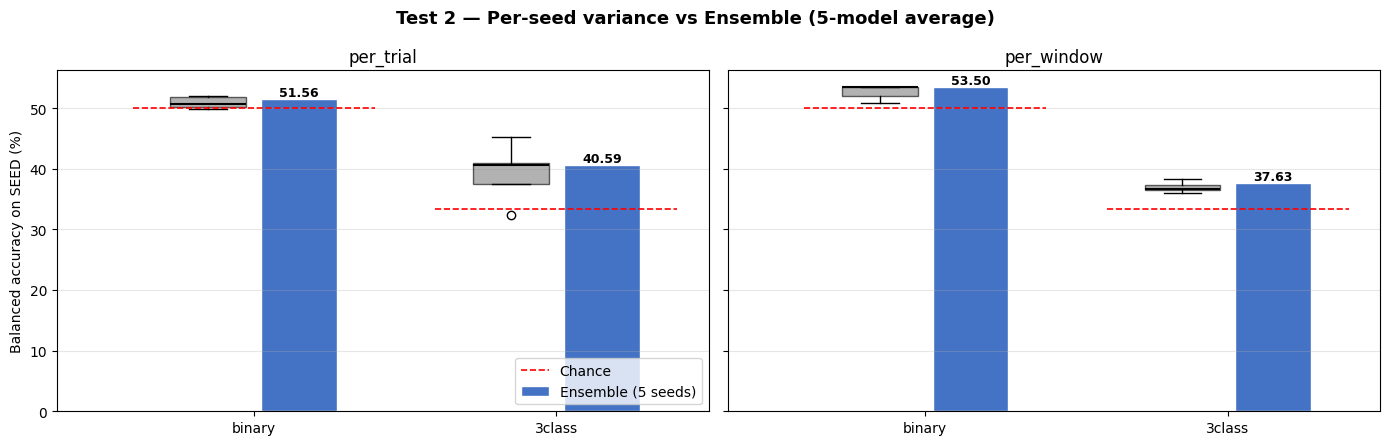

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, protocol in zip(axes, ['per_trial', 'per_window']):
    labels = []
    seeds_data = []
    ensembles = []
    for mapping in ['binary', '3class']:
        key = (mapping, protocol)
        if key not in ALL_RESULTS: continue
        r = ALL_RESULTS[key]
        labels.append(f'{mapping}')
        seeds_data.append([100*b for b in r['per_seed_bals']])
        ensembles.append(100 * r['ensemble_bal'])

    x = np.arange(len(labels))
    # Boxplot for per-seed variance
    bp = ax.boxplot(seeds_data, positions=x-0.15, widths=0.25, patch_artist=True,
                    boxprops=dict(facecolor='#7f7f7f', alpha=0.6),
                    medianprops=dict(color='black', linewidth=1.5))
    # Ensemble bars
    ax.bar(x+0.15, ensembles, width=0.25, color='#4472C4', label='Ensemble (5 seeds)',
           edgecolor='white')
    for i, e in enumerate(ensembles):
        ax.text(x[i]+0.15, e + 0.5, f'{e:.2f}', ha='center', fontsize=9, fontweight='bold')

    # Chance line per mapping
    for i, m in enumerate(labels):
        ch = 50.0 if m == 'binary' else 33.3
        ax.hlines(ch, x[i]-0.4, x[i]+0.4, colors='red', linestyles='dashed',
                  linewidth=1.2, label='Chance' if i == 0 else '')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(protocol); ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Balanced accuracy on SEED (%)')
axes[0].legend(loc='lower right')
plt.suptitle('Test 2 — Per-seed variance vs Ensemble (5-model average)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test2_ensemble_variance.png', dpi=140, bbox_inches='tight')
plt.show()

### 9.2 Test 1 vs Test 2 comparison

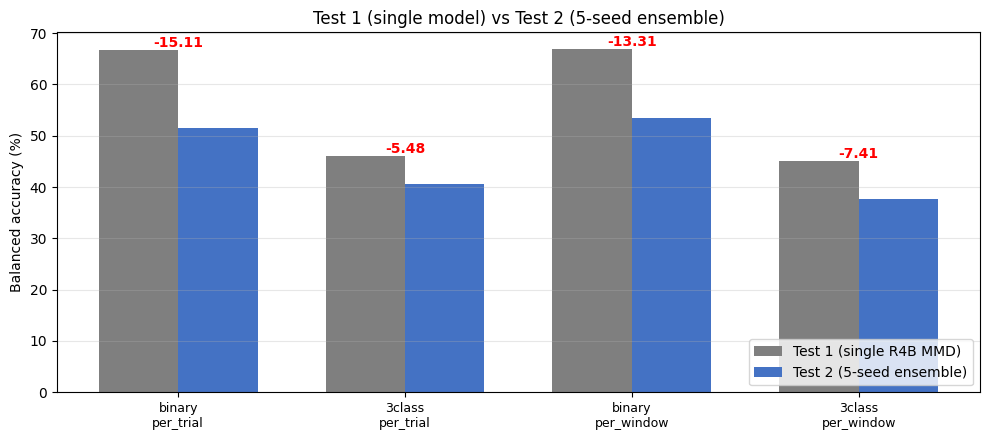

            config  Test 1 (single)  Test 2 (ensemble)      delta
 binary\nper_trial            66.67          51.555556 -15.114444
 3class\nper_trial            46.07          40.592593  -5.477407
binary\nper_window            66.81          53.503730 -13.306270
3class\nper_window            45.04          37.631028  -7.408972


In [13]:
# Test 1 single-model results (from previous run — hardcoded for reference)
TEST1_R4B_MMD = {
    ('binary',  'per_trial'):  66.67,
    ('binary',  'per_window'): 66.81,
    ('3class',  'per_trial'):  46.07,
    ('3class',  'per_window'): 45.04,
}

rows_compare = []
for (mapping, protocol), r in ALL_RESULTS.items():
    t1 = TEST1_R4B_MMD.get((mapping, protocol))
    rows_compare.append({
        'config':          f'{mapping}\n{protocol}',
        'Test 1 (single)': t1,
        'Test 2 (ensemble)': 100 * r['ensemble_bal'],
        'delta':           100 * r['ensemble_bal'] - t1,
    })

df_c = pd.DataFrame(rows_compare)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(df_c)); w = 0.35
ax.bar(x - w/2, df_c['Test 1 (single)'], w, label='Test 1 (single R4B MMD)',    color='#7f7f7f')
ax.bar(x + w/2, df_c['Test 2 (ensemble)'], w, label='Test 2 (5-seed ensemble)', color='#4472C4')

for i, row in df_c.iterrows():
    color = 'green' if row['delta'] > 0 else 'red'
    y_top = max(row['Test 1 (single)'], row['Test 2 (ensemble)'])
    ax.text(i, y_top + 0.6, f'{row["delta"]:+.2f}',
            ha='center', fontsize=10, color=color, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(df_c['config'], fontsize=9)
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Test 1 (single model) vs Test 2 (5-seed ensemble)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test2_vs_test1.png', dpi=140, bbox_inches='tight')
plt.show()

print(df_c.to_string(index=False))

## 10. Interpretation

Look at the summary CSV and plots above:

- **`single_seed_mean ± std`** — variance across 5 seeds shows how sensitive the model is to random initialization
- **`ensemble_bal`** — the ensemble result (averaged softmax probs of all 5 models)
- **`gain_from_ensemble`** — how much ensembling helped vs the average single-model

**Expected patterns:**
- If ensemble > single mean by +1-2 pp: ensembling helped (typical)
- If ensemble ≈ single mean: models agree strongly, ensemble doesn't help
- If ensemble < single mean: rare, indicates some seed produced a bad model that hurts the ensemble

**Compare to Test 1:** Test 1 used single seed = 42. If Test 2 ensemble beats Test 1's number, ensembling was worth it.